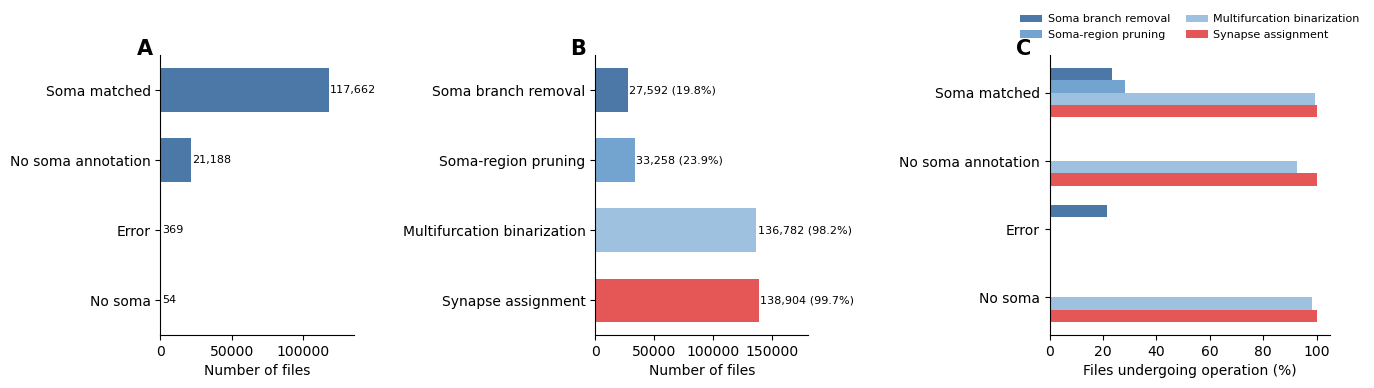

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p=Path("/data/project_backup/swc_fix/step7_out/release/meta_file.xlsx")
df=pd.read_excel(p)
df=df.loc[:,~df.columns.astype(str).str.startswith("Unnamed")]

chg=["remove_soma_branches_automatically","prun_soma_region",
     "Multifurcation_Binarization","Assign_synapse"]

for c in chg:
    df[c]=df[c].fillna(False).astype(str).str.lower().map(
        {"true":1,"false":0,"1":1,"0":0}).fillna(0).astype(int)

df["classify"]=df["classify"].fillna("Unknown").astype(str)
n=len(df)

clab={
    "soma_match_with_annotation":"Soma matched",
    "no_soma_annotation":"No soma annotation",
    "error":"Error",
    "no_soma":"No soma"
}
olab={
    "remove_soma_branches_automatically":"Soma branch removal",
    "prun_soma_region":"Soma-region pruning",
    "Multifurcation_Binarization":"Multifurcation binarization",
    "Assign_synapse":"Synapse assignment"
}
colors=["#4C78A8","#72A4CF","#9EC1DF","#E45756"]
order=["soma_match_with_annotation","no_soma_annotation","error","no_soma"]

fig,ax=plt.subplots(
    1,3,figsize=(13.5,4.2),
    gridspec_kw={"width_ratios":[1,1.1,1.45]}
)

# A
s=df["classify"].value_counts().reindex(order).dropna()
y=np.arange(len(s))
ax[0].barh(y,s,color=colors[0],height=.62)
ax[0].set_yticks(y,[clab[x] for x in s.index])
ax[0].invert_yaxis()
ax[0].set_xlabel("Number of files")
ax[0].set_xlim(0,s.max()*1.15)
for i,v in enumerate(s):
    ax[0].text(v+s.max()*.008,i,f"{int(v):,}",va="center",fontsize=8)

# B
s=df[chg].sum()
y=np.arange(len(chg))
ax[1].barh(y,s,color=colors,height=.62)
ax[1].set_yticks(y,[olab[c] for c in chg])
ax[1].invert_yaxis()
ax[1].set_xlabel("Number of files")
ax[1].set_xlim(0,s.max()*1.30)
for i,v in enumerate(s):
    ax[1].text(v+s.max()*.008,i,
               f"{v:,} ({v/n*100:.1f}%)",
               va="center",fontsize=8)

# C
g=df.groupby("classify")[chg].mean()*100
g=g.reindex(order).dropna(how="all")

y=np.arange(len(g))
h=.18
for i,c in enumerate(chg):
    ax[2].barh(y+(i-1.5)*h,g[c],h,
               color=colors[i],label=olab[c])

ax[2].set_yticks(y,[clab[x] for x in g.index])
ax[2].invert_yaxis()
ax[2].set_xlim(0,105)
ax[2].set_xlabel("Files undergoing operation (%)")
ax[2].legend(
    frameon=False,fontsize=8,ncol=2,
    loc="lower center",bbox_to_anchor=(.5,1.02),
    columnspacing=1.4,handletextpad=.5
)

for a,l in zip(ax,"ABC"):
    a.spines[["top","right"]].set_visible(False)
    a.tick_params(direction="out")
    a.text(-.12,1.06,l,transform=a.transAxes,
           fontsize=15,fontweight="bold",va="top")

plt.tight_layout(w_pad=2.5,rect=[0,0,1,.95])
plt.savefig(p.parent/"repair_summary_figure.png",dpi=600,bbox_inches="tight")
plt.savefig(p.parent/"repair_summary_figure.pdf",bbox_inches="tight")
plt.show()